<a href="https://colab.research.google.com/github/Mitanshi27/MSTAR-Target-Classification/blob/main/hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from PIL import Image
import os
from google.colab import drive
import cv2
import xgboost as xgb


In [6]:
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!unzip "/content/drive/MyDrive/archive.zip" -d "/content/mstar"


In [ ]:
data_dir = "/content/mstar/Padded_imgs"  # or wherever your root folder is

image_data = []
labels = []
classes = sorted(os.listdir(data_dir))


for class_idx, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)

    # Make sure it's a folder
    if not os.path.isdir(class_path):
        print(f"Skipping non-folder: {class_path}")
        continue

    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)

        if not img_file.lower().endswith('.jpg'):
            print(f"Skipping non-image file: {img_path}")
            continue

        try:
            img = Image.open(img_path).convert("L").resize((128, 128))
            image_data.append(np.array(img))
            labels.append(class_idx)
        except Exception as e:
            print(f"Error loading image: {img_path} — {e}")


In [ ]:
print(f"Total images loaded: {len(image_data)}")


Total images loaded: 9466


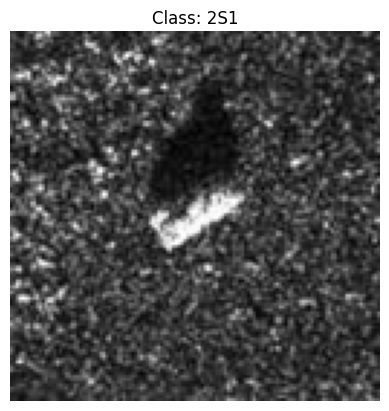

In [ ]:
idx = 0
plt.imshow(image_data[idx], cmap='gray')
plt.title(f"Class: {classes[labels[idx]]}")
plt.axis('off')
plt.show()

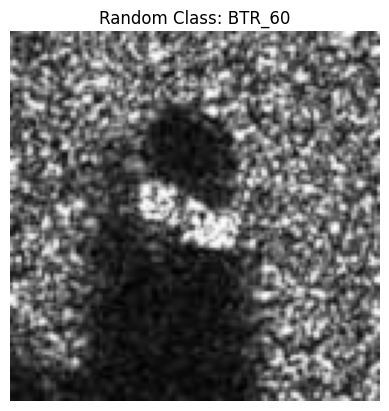

In [ ]:
import random

idx = random.randint(0, len(image_data)-1)
plt.imshow(image_data[idx], cmap='gray')
plt.title(f"Random Class: {classes[labels[idx]]}")
plt.axis('off')
plt.show()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

DATA_DIR = '/content/mstar/Padded_imgs'
IMG_SIZE = (64, 64)  # Resize dimensions
X, y = [], []

# Load all images
for label in os.listdir(DATA_DIR):
    class_dir = os.path.join(DATA_DIR, label)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            try:
                img = load_img(img_path, target_size=IMG_SIZE, color_mode='grayscale')
                img_array = img_to_array(img) / 255.0  # Normalize
                X.append(img_array)
                y.append(label)
            except Exception as e:
                print(f"Skipped {img_path}: {e}")

# Convert to arrays
X = np.array(X)
y = np.array(y)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical)

print(f"Loaded {len(X)} images across {len(le.classes_)} classes.")
print("Classes:", le.classes_)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')  # 8 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


In [ ]:
 import matplotlib.pyplot as plt

# Assuming `history` is your model training output
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='purple')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='blue')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

plt.tight_layout()
plt.show()


60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step


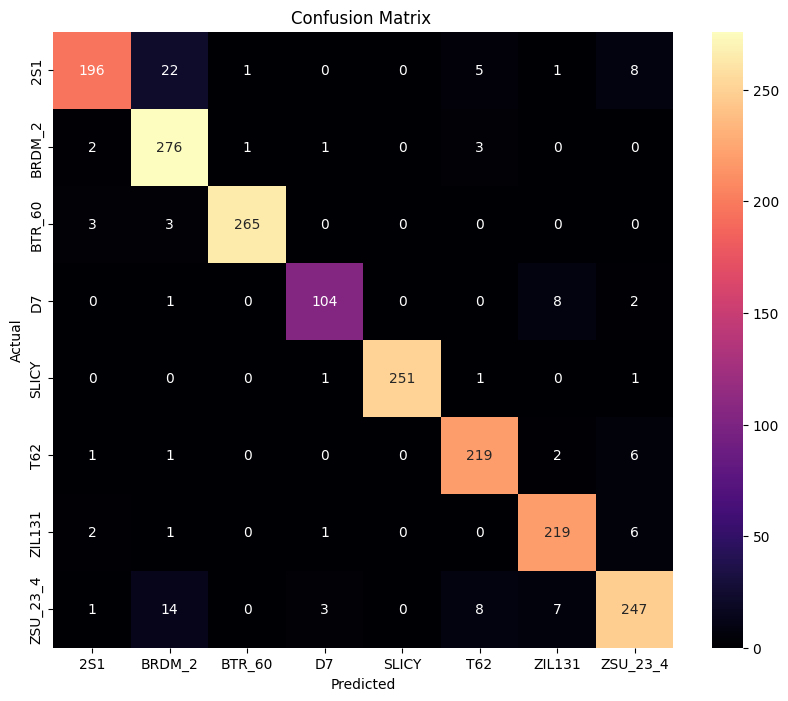

              precision    recall  f1-score   support

         2S1       0.96      0.84      0.89       233
      BRDM_2       0.87      0.98      0.92       283
      BTR_60       0.99      0.98      0.99       271
          D7       0.95      0.90      0.92       115
       SLICY       1.00      0.99      0.99       254
         T62       0.93      0.96      0.94       229
      ZIL131       0.92      0.96      0.94       229
    ZSU_23_4       0.91      0.88      0.90       280

    accuracy                           0.94      1894
   macro avg       0.94      0.94      0.94      1894
weighted avg       0.94      0.94      0.94      1894



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix ')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [ ]:
def superimpose_gradcam(heatmap, img, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap_color * alpha + img
    return np.uint8(superimposed_img)


In [ ]:
sample_index = 42  # or whatever makes sense
img = X_test[sample_index]  # shape: (64, 64, 1), values: 0-1
img_array = np.expand_dims(img, axis=0)


In [ ]:
model.build(input_shape=(None, 64, 64, 1))  # This builds it manually
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,052,762 (7.83 MB)

 Trainable params: 684,104 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 1,368,210 (5.22 MB)

In [ ]:
import numpy as np


model.fit(X_train_flat, y_train_indices)
preds = model.predict(X_test_flat)
acc = accuracy_score(y_test_indices, preds)


In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

y_train_indices = np.argmax(y_train, axis=1)
y_test_indices = np.argmax(y_test, axis=1)
results={}

# === Define Models ===
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier()
}

# === Train & Evaluate ===
for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train_flat, y_train_indices)
    preds = model.predict(X_test_flat)

    acc = accuracy_score(y_test_indices, preds)
    results[name] = acc
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_indices, preds, target_names=le.classes_))


# === Plot Comparison ===
plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="coolwarm")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



 Training Logistic Regression...
Accuracy: 0.9725
              precision    recall  f1-score   support

         2S1       0.93      0.92      0.92       233
      BRDM_2       0.93      0.94      0.93       283
      BTR_60       1.00      1.00      1.00       271
          D7       0.98      0.99      0.99       115
       SLICY       0.99      0.98      0.99       254
         T62       0.98      1.00      0.99       229
      ZIL131       1.00      1.00      1.00       229
    ZSU_23_4       0.97      0.96      0.97       280

    accuracy                           0.97      1894
   macro avg       0.97      0.97      0.97      1894
weighted avg       0.97      0.97      0.97      1894


 Training Decision Tree...
Accuracy: 0.7149
              precision    recall  f1-score   support

         2S1       0.52      0.45      0.48       233
      BRDM_2       0.63      0.57      0.60       283
      BTR_60       0.90      0.99      0.94       271
          D7       0.57      0.51   

In [3]:
from sklearn.metrics import confusion_matrix, classification_report

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

y_train_indices = np.argmax(y_train, axis=1)
y_test_indices = np.argmax(y_test, axis=1)
results={}

# === Define Models ===
models = {

    "Random Forest": RandomForestClassifier(n_estimators=100),

}

# === Train & Evaluate ===
for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train_flat, y_train_indices)
    preds = model.predict(X_test_flat)

    acc = accuracy_score(y_test_indices, preds)
    results[name] = acc
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test_indices, preds, target_names=le.classes_))


# === Plot Comparison ===
plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="coolwarm")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


NameError: name 'X_train' is not defined

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X_train_flat, y_train)
print(grid_search.best_params_)


{'max_depth': 15, 'n_estimators': 50}


In [2]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(5, 20)
}

random_search = RandomizedSearchCV(RandomForestClassifier(), param_distributions=param_dist, n_iter=10, cv=5)
random_search.fit(X_train, y_train)
print(random_search.best_params_)


NameError: name 'RandomForestClassifier' is not defined

In [ ]:
!pip install optuna
import optuna

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
    rf.fit(X_train_flat , y_train)
    preds = rf.predict(X_test_2D)
    return accuracy_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best trial:", study.best_trial.params)


In [ ]:
X_train_2D = X_train.reshape(X_train.shape[0], -1)
X_test_2D = X_test.reshape(X_test.shape[0], -1)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data (replace with your actual results)
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'Gradient Boosting'],
    'Accuracy (Before Tuning)': [0.97, 0.72, 0.86, 0.88, 0.91],
    'Accuracy (After Tuning)': [0.975, 0.78, 0.89, 0.90, 0.93]
}

df = pd.DataFrame(results)

# Bar chart comparison
df.set_index('Model').plot(kind='bar', figsize=(10, 6), rot=45, colormap='viridis')
plt.title("Model Accuracy Comparison (Before vs After Tuning)")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()


In [ ]:
best_model = df.iloc[df['Accuracy (After Tuning)'].idxmax()]
print(f" Best Overall: {best_model['Model']} with {best_model['Accuracy (After Tuning)']*100:.2f}% accuracy.")


In [1]:
pip install streamlit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00


In [13]:
# Save this as app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Data
df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Before Tuning': [0.97, 0.72, 0.86],
    'After Tuning': [0.975, 0.78, 0.89]
})

st.title("Model Performance Dashboard")
st.bar_chart(df.set_index('Model'))


2025-04-12 11:59:45.040 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 11:59:45.124 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-12 11:59:45.124 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 11:59:45.421 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 11:59:45.422 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [1]:
streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py

SyntaxError: invalid syntax (<ipython-input-1-fabc432b94c1>, line 1)